In [1]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.join(os.getcwd(), "ForceSMIP"))

# Import our modules
from data_loader import ForceSMIPDataLoader, yearly_average, compute_yearly_average_dict
from preprocessing import (
    merge_training_data, reshape_training_data, 
    apply_notnan_filter_complete
)
from algorithms import WeightedRidgeRegression, ridge_regression, LowRankSolver
from evaluation import ForceSMIPEvaluator, compute_trends_from_data, compute_statistics
from visualization import ForceSMIPVisualizer
from forcesmip_pipeline import ForceSMIPPipeline

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Modules loaded successfully!")


Modules loaded successfully!


In [2]:
# Initialize pipeline
base_path = '/net/krypton/climdyn_nobackup/FTP'

# variable names: pr, psl, tas, tos
variable = 'psl'  # Sea Level Pressure

pipeline = ForceSMIPPipeline(base_path, variable=variable)
print(f"Pipeline initialized for variable: {variable}")

Pipeline initialized for variable: psl


In [3]:
# Initialize data loader
data_loader = ForceSMIPDataLoader(base_path)

# Load training data
print("Loading training data...")
dic_data, dic_forced_response, longitude, latitude = data_loader.load_training_data(variable)

print(f"Training data loaded:")
print(f"  Number of models: {len(dic_data)}")
print(f"  Model names: {list(dic_data.keys())}")
print(f"  Grid shape: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"  Time steps: {list(dic_data.values())[0].shape[1]}")

Loading training data...
Processing 1/5: CESM2
  Processing 1/50: psl_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: psl_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: psl_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: psl_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: psl_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: psl_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: psl_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: psl_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: psl_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: psl_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: psl_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: psl_mon

In [4]:
# Initialize data loader
data_loader = ForceSMIPDataLoader(base_path)

# Load test data
test_models = ['2A', '2B', '2C', '2D', '2E', '2F', '2G', '2H', '2I', '2J', '2K', '2L', '2M', '2N', '2O', '2P', '2Q', '2R', '2S', '2T', '2U']
print("\nLoading test data...")
data_test, temporal_means = data_loader.load_test_data(variable, tier='Tier2', test_models=test_models)


print(f"Test data shape: {data_test.shape}")


Loading test data...
Files in test data directory: ['psl_mon_2A.190001-202312.nc', 'psl_mon_2B.190001-202312.nc', 'psl_mon_2C.190001-202312.nc', 'psl_mon_2D.190001-202312.nc', 'psl_mon_2E.190001-202312.nc', 'psl_mon_2F.190001-202312.nc', 'psl_mon_2G.190001-202312.nc', 'psl_mon_2H.190001-202312.nc', 'psl_mon_2I.190001-202312.nc', 'psl_mon_2J.190001-202312.nc', 'psl_mon_2K.190001-202312.nc', 'psl_mon_2L.190001-202312.nc', 'psl_mon_2M.190001-202312.nc', 'psl_mon_2N.190001-202312.nc', 'psl_mon_2O.190001-202312.nc', 'psl_mon_2P.190001-202312.nc', 'psl_mon_2Q.190001-202312.nc', 'psl_mon_2R.190001-202312.nc', 'psl_mon_2S.190001-202312.nc', 'psl_mon_2T.190001-202312.nc', 'psl_mon_2U.190001-202312.nc']
Loading test data for 2A at index 0
create data_test array
Monthly centering
Loading test data for 2B at index 1
Monthly centering
Loading test data for 2C at index 2
Monthly centering
Loading test data for 2D at index 3
Monthly centering
Loading test data for 2E at index 4
Monthly centering
Loa

In [11]:
range(temporal_means.shape[1])

range(0, 1488)

In [16]:
L = np.arange(temporal_means.shape[1])
L = L[L%12==0]

In [18]:
temporal_means[0,L,0,0]

array([101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 101255.23, 101255.23,
       101255.23, 101255.23, 101255.23, 101255.23, 

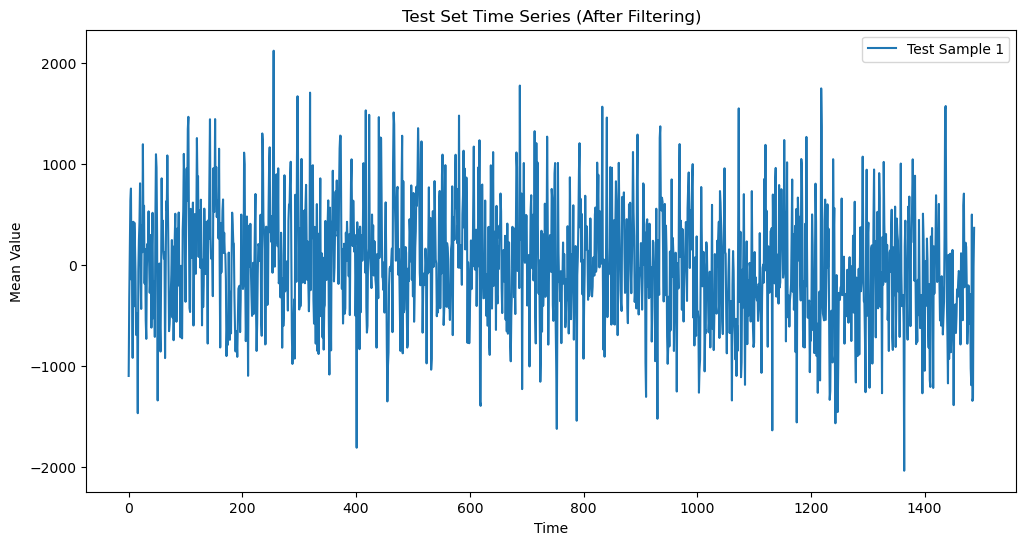

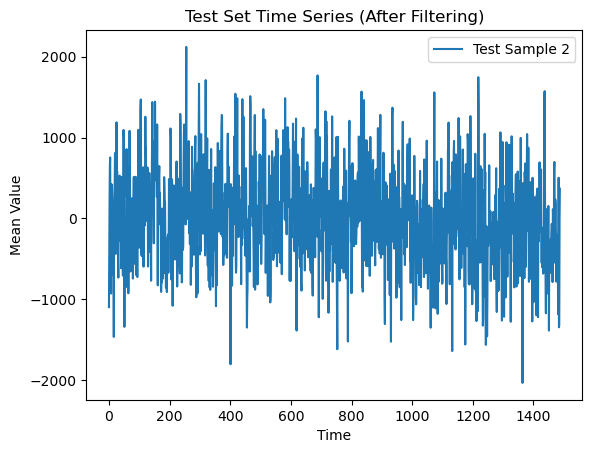

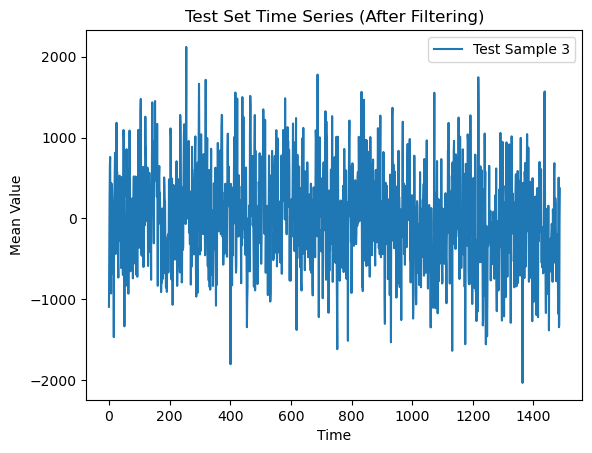

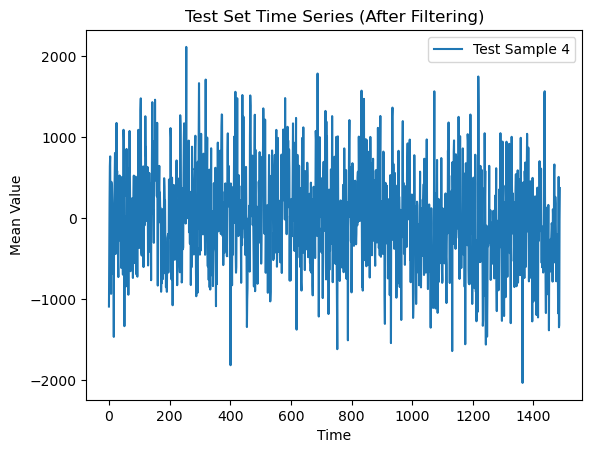

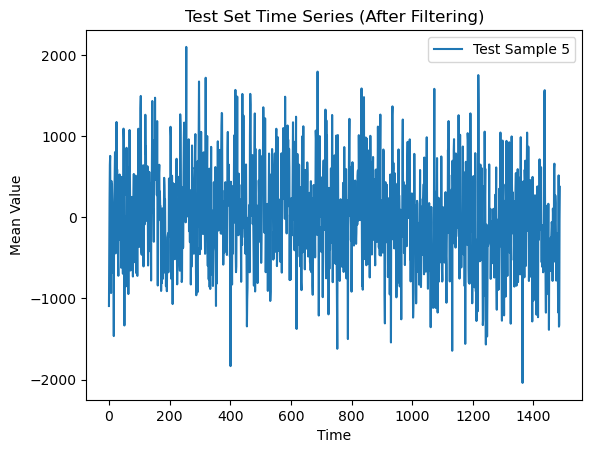

In [5]:
# display some time series of the test set

plt.figure(figsize=(12, 6))
for i in range(5):  # Plot up to 30 samples
    plt.plot(data_test[0,:,:,:].reshape(data_test.shape[1],-1)[:,i], label=f'Test Sample {i+1}')
    plt.title('Test Set Time Series (After Filtering)')
    plt.xlabel('Time')
    plt.ylabel('Mean Value')
    plt.legend()
    plt.show()    

In [6]:
# import netCDF4 as nc

# file_path = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Evaluation-Tier2/Amon/pr/pr_mon_2O.190001-202312.nc'

# with nc.Dataset(file_path, 'r') as nc_file:
#     time = np.array(nc_file.variables['time'])
#     data = np.array(nc_file.variables['pr'])
#     # data[np.abs(data) > 1e9] = np.nan  # Handle missing values

# # data_tmp = data.copy()
# # data_tmp[np.abs(data_tmp) > 1e9] = np.nan  # Handle missing values

# # Monthly centering
# for i in range(12):
#     month_mask = np.arange(time.shape[0]) % 12 == i
#     monthly_mean = np.nanmean(data_tmp[month_mask, :, :], axis=0)
#     data[month_mask, :, :] -= monthly_mean

# Data processing

In [7]:
# Compute yearly averages
print("Computing yearly averages...")
dic_data_yearly = compute_yearly_average_dict(dic_data)
dic_forced_response_yearly = compute_yearly_average_dict(dic_forced_response)

data_test_yearly = yearly_average(data_test)
# data_ground_truth_yearly = yearly_average(data_ground_truth)

print(f"Yearly data shape (first model): {list(dic_data_yearly.values())[0].shape}")
print(f"Test yearly shape: {data_test_yearly.shape}")

Computing yearly averages...


Yearly data shape (first model): (50, 221, 72, 144)
Test yearly shape: (21, 124, 72, 144)


In [8]:
# Prepare training data for machine learning
print("Preparing training data...")

# Method 1: Merge all training data
x_train_merged, y_train_merged = merge_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

# Method 2: Keep model separation
x_train_dict, y_train_dict = reshape_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

print(f"Merged training data shape: X={x_train_merged.shape}, Y={y_train_merged.shape}")
print(f"Separated training data: {len(x_train_dict)} models")

Preparing training data...
Merged training data shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Separated training data: 5 models


# Capture the NaNs of the data

In [9]:
def capture_nans(x_train_dict):
    """
    Capture indices of NaN values across all training data.
    Args:
        x_train_dict (dict): Dictionary of training data tensors with keys as model names.
    Returns:
        nan_union (list): List of indices where NaN values are found across all models.
        notnan_inter (list): List of indices where no NaN values are found across all models.
    """
    
    # enumerate in the dictionary and get the union of the nans for each pair ((key, value))
    for (key, value) in x_train_dict.items():
        # nan_indices = list(torch.where(torch.abs(value[0,:,:]) > 1e9)[0].numpy())

        # new code to test 
        # get nan mask of test set 
        nan_mask = np.where(np.abs(value[0,:,:])>1e10, True, False)
        nan_mask = np.where(np.isnan(value[0,:,:])==True, True, False)

        # get the index of columns where there is at least one True in the nan mask
        col_indices = np.where(np.any(nan_mask, axis=0))[0]

        if 'nan_union' not in locals():
            nan_union = col_indices
        else:
            nan_union = list(set(nan_union) | set(col_indices))

    notnan_inter = list(set(range(value.shape[2])) - set(nan_union))

    return nan_union, notnan_inter

In [10]:
nan_idx, notnan_idx =capture_nans(x_train_dict)

# Prepare test data for smoothing experiments
x_test = torch.from_numpy(data_test.reshape(
    data_test.shape[0], data_test.shape[1], -1
)).to(torch.float32)

print(f"Test data shape for smoothing: {x_test.shape}")

Test data shape for smoothing: torch.Size([21, 1488, 10368])


/tmp/ipykernel_20900/532908718.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.abs(value[0,:,:])>1e10, True, False)
/tmp/ipykernel_20900/532908718.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.isnan(value[0,:,:])==True, True, False)


In [11]:
# add the nans that are also included in the test data
# record nan indices as the union of nans on each map
nan_idx_test = nan_idx.copy()

for idx_r in range(x_test.shape[0]):

    # get nan mask of test set 
    nan_mask = np.where(np.abs(x_test[idx_r,:,:])>1e10, True, False)
    nan_mask = np.where(np.isnan(x_test[idx_r,:,:])==True, True, False)

    # get the index of columns where there is at least one True in the nan mask
    col_indices = np.where(np.any(nan_mask, axis=0))[0]

    nan_idx_test = list(set(nan_idx_test) | set(col_indices))    

# define not nan indices (useful to ease the computations)
notnan_idx_test = list(set(list(range(x_test.shape[2]))) - set(nan_idx_test))
    

# # replace the nan index by Nans
notnan_idx = notnan_idx_test
nan_idx = nan_idx_test

/tmp/ipykernel_20900/3197768795.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.abs(x_test[idx_r,:,:])>1e10, True, False)
/tmp/ipykernel_20900/3197768795.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.isnan(x_test[idx_r,:,:])==True, True, False)


In [12]:
# Apply not-NaN filter to all data
x_train_merged_filtered, y_train_merged_filtered, \
x_train_dict_filtered, y_train_dict_filtered, x_test_filtered = apply_notnan_filter_complete(
    x_train_merged, y_train_merged,
    x_train_dict, y_train_dict,
    x_test, notnan_idx
)

              APPLYING NOT-NAN FILTER TO ALL DATA
Valid indices count: 10368

1. Filtering merged training data...
   X: torch.Size([40885, 10368]) -> torch.Size([40885, 10368])
   Y: torch.Size([40885, 10368]) -> torch.Size([40885, 10368])

2. Filtering training dictionaries...
Filtering training dictionaries...
Keeping 10368 valid spatial features
CESM2: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 10368])
CanESM5: X torch.Size([25, 221, 10368]) -> torch.Size([25, 221, 10368])
MIROC-ES2L: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 10368])
MIROC6: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 10368])
MPI-ESM1-2-LR: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 10368])

3. Filtering test data...
   Test: torch.Size([21, 1488, 10368]) -> torch.Size([21, 1488, 10368])

=== FILTERING SUMMARY ===
Original spatial features: 10368
Filtered spatial features: 10368
Features removed: 0
Reduction: 0.0%


# Run the ridge regression model

In [13]:
# build a weight matrix (latitude, longitude) where each grid cell is weighted by its surface area
weights = np.cos(np.radians(latitude))

# duplicate weights for each longitude
surface = torch.from_numpy(np.tile(weights[:, np.newaxis], (1, longitude.shape[0]))).to(torch.float32).flatten()
surface = surface[notnan_idx_test]

# Updated cell for model training
# Train global ridge regression model
lambda_reg = 2000.0
# print(f"Training ridge regression with lambda={lambda_reg}...")

w_ridge = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, lambda_reg, surface=None, verbose=True)
# print(f"Ridge weights shape: {w_ridge.shape}")

Solving ridge regression with λ=2000.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])


Ridge weights computed: torch.Size([10368, 10368])


In [14]:
# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.fit(x_train_merged_filtered, y_train_merged_filtered, lambda_reg=lambda_reg, surface=None, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [5, 10, 15, 20, 25, 30, 50]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)

# Print explained variance for different ranks
print(f"\nExplained variance by rank:")
cumulative_var = lr_solver.cumulative_variance_ratio()
for rank in ranks_to_test:
    if rank <= len(cumulative_var):
        print(f"  Rank {rank}: {cumulative_var[rank-1]:.4f}")

# Use the primary rank solution
primary_rank = 30
w_ridge_lr = rank_solutions[primary_rank]
print(f"Primary rank-{primary_rank} weights shape: {w_ridge_lr.shape}")


Setting up low-rank solver...
Computing SVD for low-rank approximations...
Solving ridge regression with λ=2000.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])
SVD computed: U=torch.Size([51253, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.001313 to 295307.718750
Computed solutions for ranks: [5, 10, 15, 20, 25, 30, 50]

Explained variance by rank:
  Rank 5: 0.9843
  Rank 10: 0.9951
  Rank 15: 0.9970
  Rank 20: 0.9980
  Rank 25: 0.9985
  Rank 30: 0.9988
  Rank 50: 0.9995
Primary rank-30 weights shape: torch.Size([10368, 10368])


### Smoothing

In [15]:
# # do some smoothing
from preprocessing import moving_average_smoothing


# x_test_filtered[np.abs(x_test_filtered)>1e10] = 0.0
x_test_smooth = moving_average_smoothing(x_test_filtered, window_size=12*20, mode='same')

In [16]:
# Make predictions using different methods
print("Making predictions...")

# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

y_pred_ridge_smooth = x_test_smooth @ w_ridge
y_pred_ridge_lr_smooth = x_test_smooth @ w_ridge_lr

Making predictions...


In [17]:
# ##
# y_pred_ridge = y_pred_ridge.flatten()
# y_pred_ridge[get_flat_nans] = 0.0
# y_pred_ridge = y_pred_ridge.reshape(data_test.shape[0], data_test.shape[1], -1)

In [18]:
# Initialize evaluator
evaluator = ForceSMIPEvaluator()

# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = np.reshape(pred_numpy, (pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2]))
    print(f"Pred yearly shape (before mean): {pred_yearly.shape}")
    pred_yearly = np.nanmean(pred_yearly, axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(0, None)  # Last 43 years for trend computation


# trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_smooth = to_yearly_and_trends(y_pred_ridge_smooth, trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_ridge_lr_smooth = to_yearly_and_trends(y_pred_ridge_lr_smooth, trend_years)


print(f"Trend shape: {trends_ridge.shape}")

Pred yearly shape (before mean): (21, 124, 12, 10368)


Pred yearly shape (before mean): (21, 124, 12, 10368)
Pred yearly shape (before mean): (21, 124, 12, 10368)
Pred yearly shape (before mean): (21, 124, 12, 10368)
Trend shape: (21, 10368)


# Visualization

In [19]:
# Initialize visualizer
visualizer = ForceSMIPVisualizer(longitude, latitude, test_models)

# reshape the trends for visualization
trends_ridge_fullmap = np.zeros((trends_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_fullmap[:,notnan_idx] = trends_ridge
trends_ridge_fullmap[:,nan_idx] = np.nan  # --- IGNORE ---
# trends_ridge_fullmap[:,nan_idx_test] = np.nan  # Fill NaNs for visualization

# reshape the trends for visualization
trends_ridge_smooth_fullmap = np.zeros((trends_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_smooth_fullmap[:,notnan_idx] = trends_ridge_smooth
trends_ridge_smooth_fullmap[:,nan_idx] = np.nan  # --- IGNORE ---
# trends_ridge_smooth_fullmap[:,nan_idx_test] = np.nan  # Fill NaNs for visualization


trends_ridge_lr_fullmap = np.zeros((trends_ridge_lr.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_lr_fullmap[:,notnan_idx] = trends_ridge_lr
trends_ridge_lr_fullmap[:,nan_idx] = np.nan  # --- IGNORE ---
# trends_ridge_lr_fullmap[:,nan_idx_test] = np.nan  # Fill NaNs for visualization

trends_ridge_lr_smooth_fullmap = np.zeros((trends_ridge_lr.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_lr_smooth_fullmap[:,notnan_idx] = trends_ridge_lr_smooth  
trends_ridge_lr_smooth_fullmap[:,nan_idx] = np.nan  # --- IGNORE ---
# trends_ridge_lr_smooth_fullmap[:,nan_idx_test] = np.nan


Using vmin=-1.9908785820007324, vmax=1.9908785820007324 for colorbar
Using vmin=-2.180419445037842, vmax=2.180419445037842 for colorbar
Using vmin=-1.4956284761428833, vmax=1.4956284761428833 for colorbar
Using vmin=-1.0503778457641602, vmax=1.0503778457641602 for colorbar
Using vmin=-2.071688652038574, vmax=2.071688652038574 for colorbar
Using vmin=-1.631702184677124, vmax=1.631702184677124 for colorbar
Using vmin=-1.1846929788589478, vmax=1.1846929788589478 for colorbar
Using vmin=-1.5690529346466064, vmax=1.5690529346466064 for colorbar
Using vmin=-3.29103946685791, vmax=3.29103946685791 for colorbar
Using vmin=-1.0801995992660522, vmax=1.0801995992660522 for colorbar
Using vmin=-1.1778395175933838, vmax=1.1778395175933838 for colorbar
Using vmin=-9.727811813354492, vmax=9.727811813354492 for colorbar
Using vmin=-1.681665062904358, vmax=1.681665062904358 for colorbar
Using vmin=-0.7920854687690735, vmax=0.7920854687690735 for colorbar
Using vmin=-1.311818242073059, vmax=1.3118182420

/home/vcohen/cope/ForceSMIP/visualization.py:119: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(15, 8))


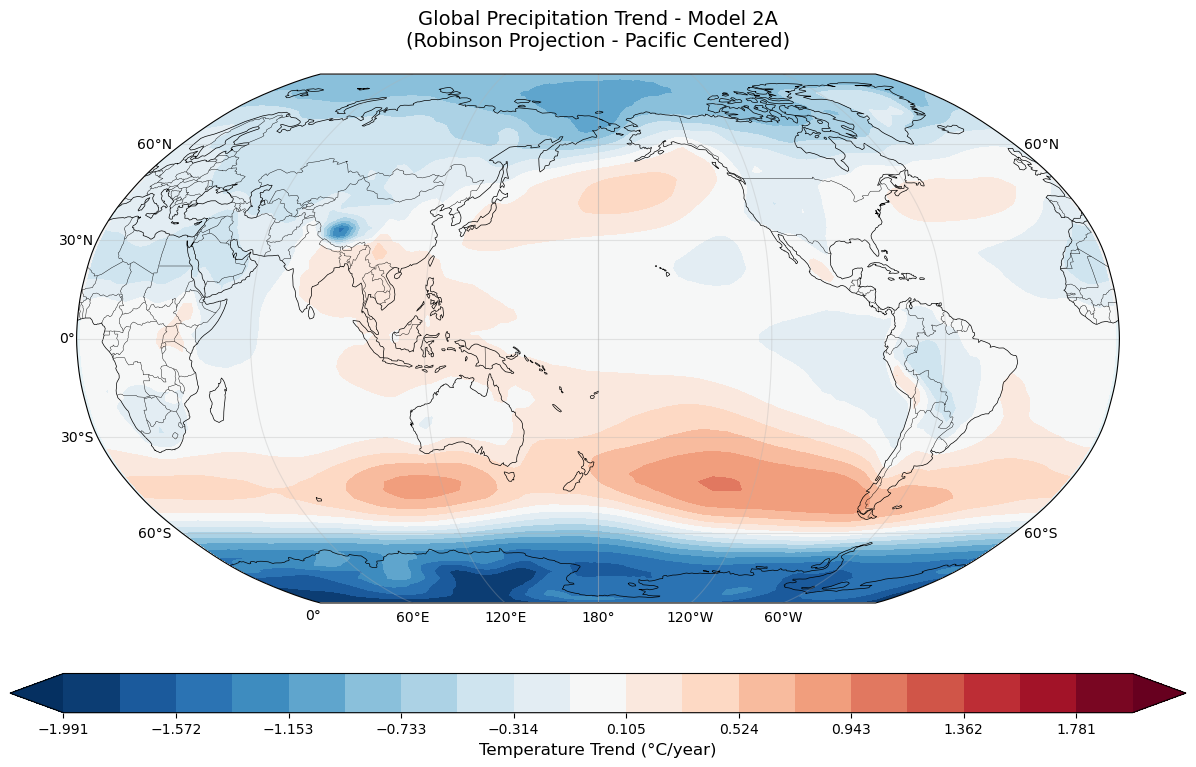

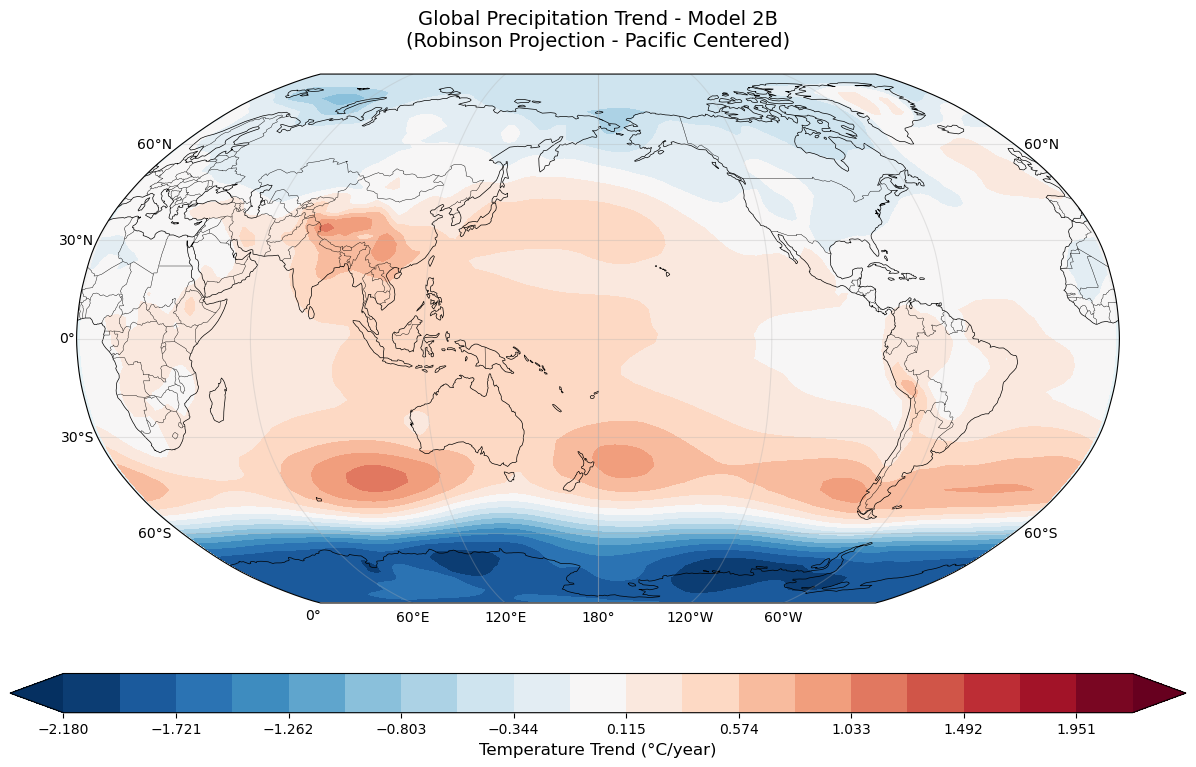

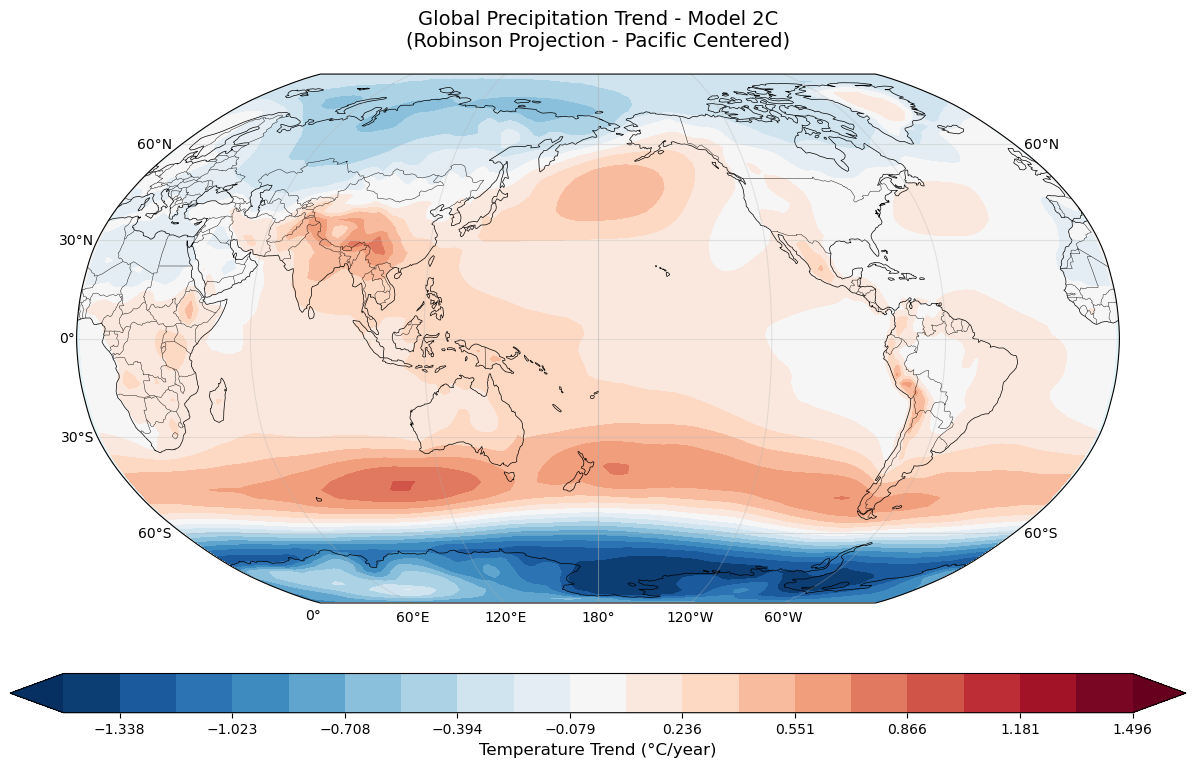

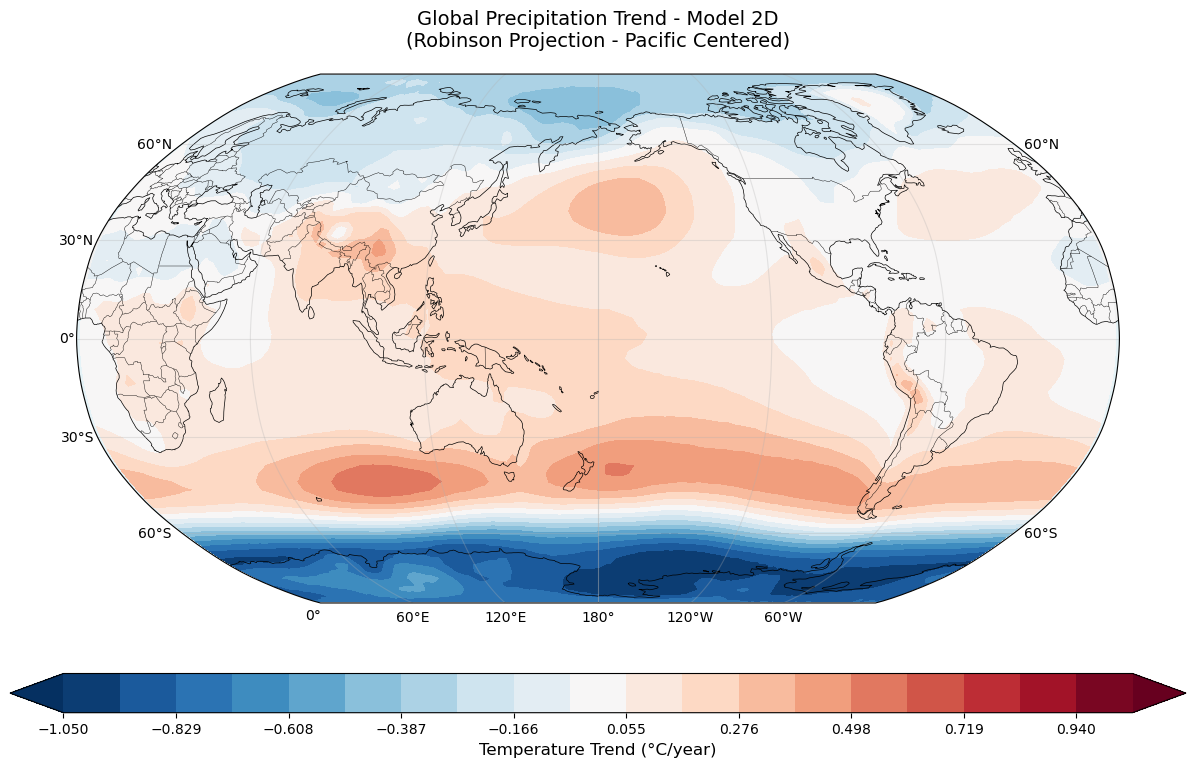

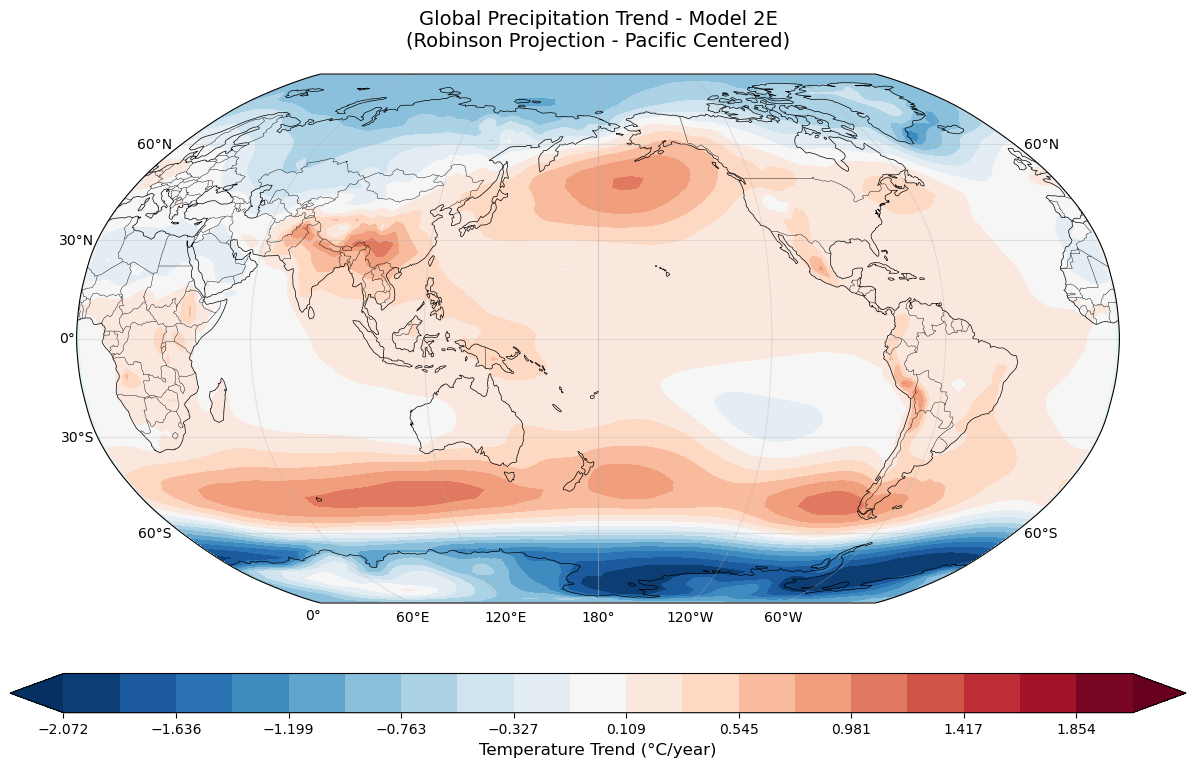

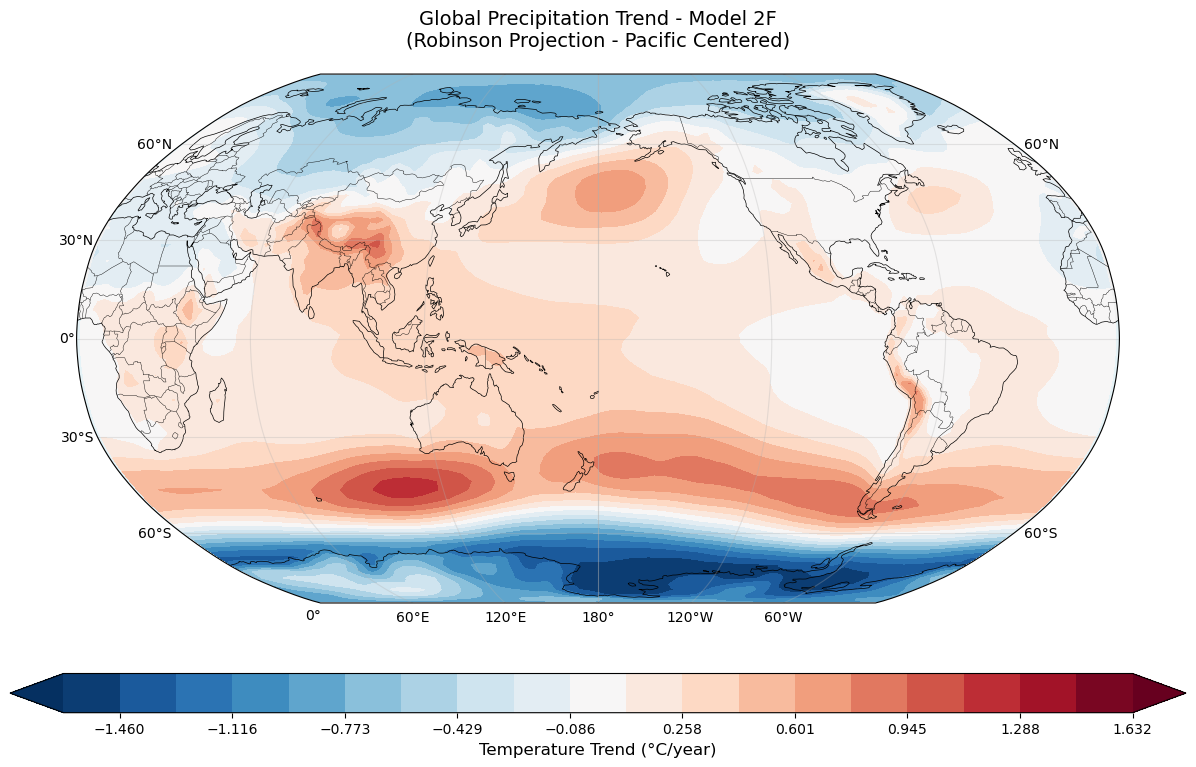

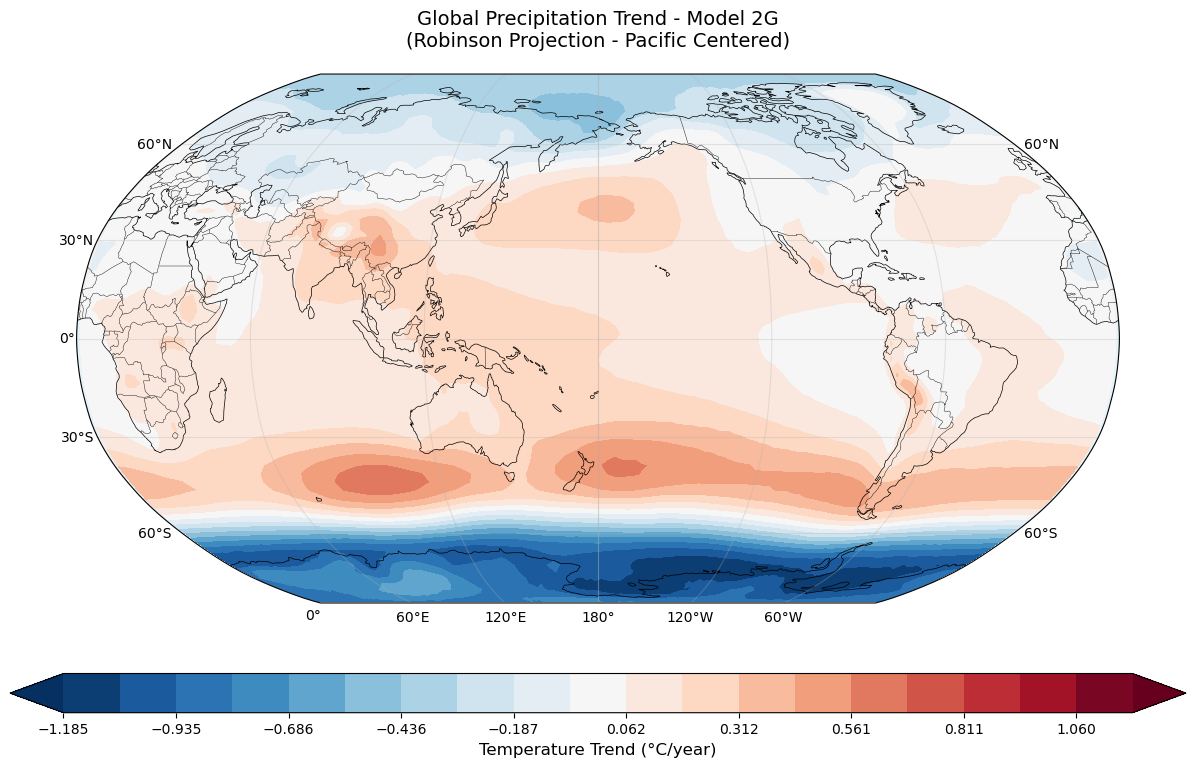

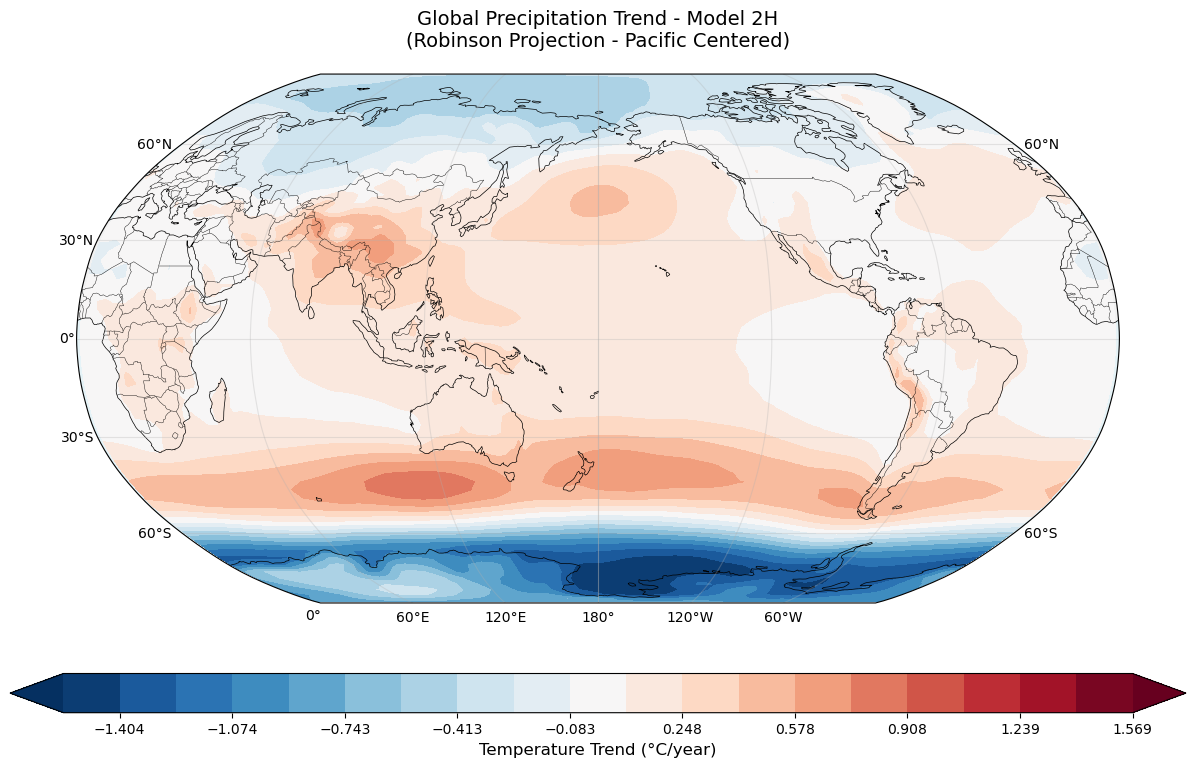

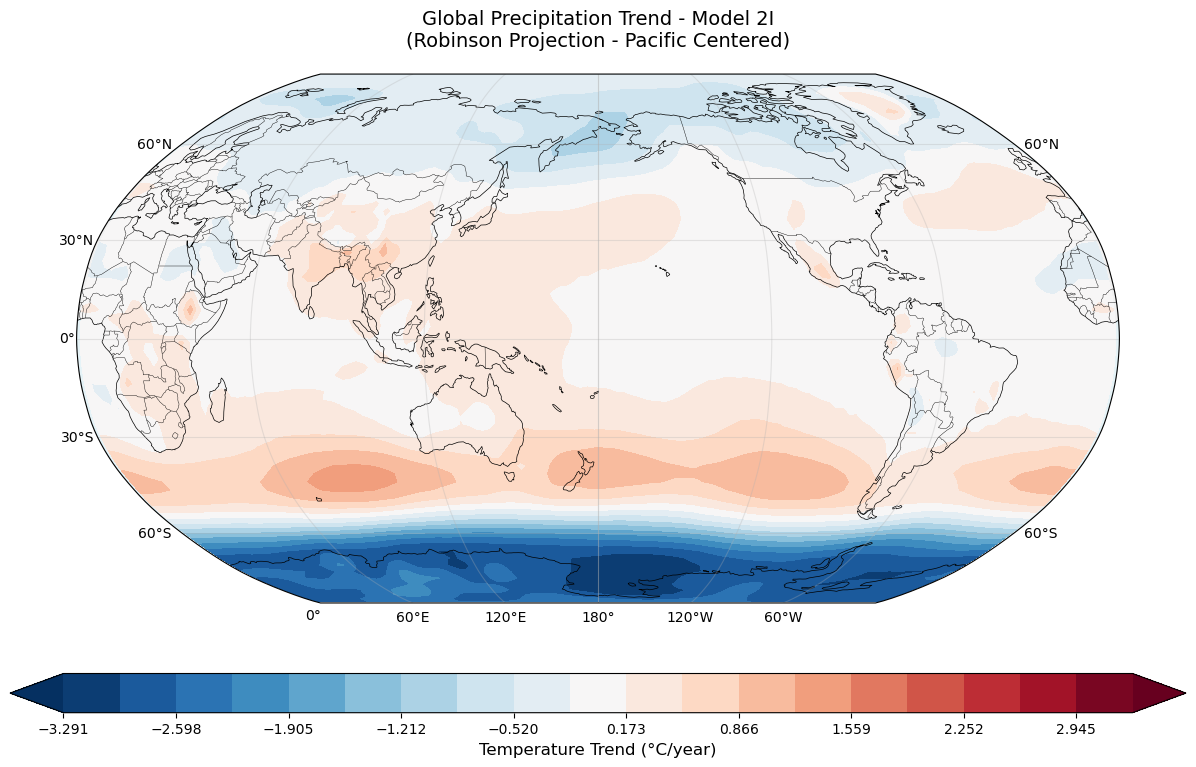

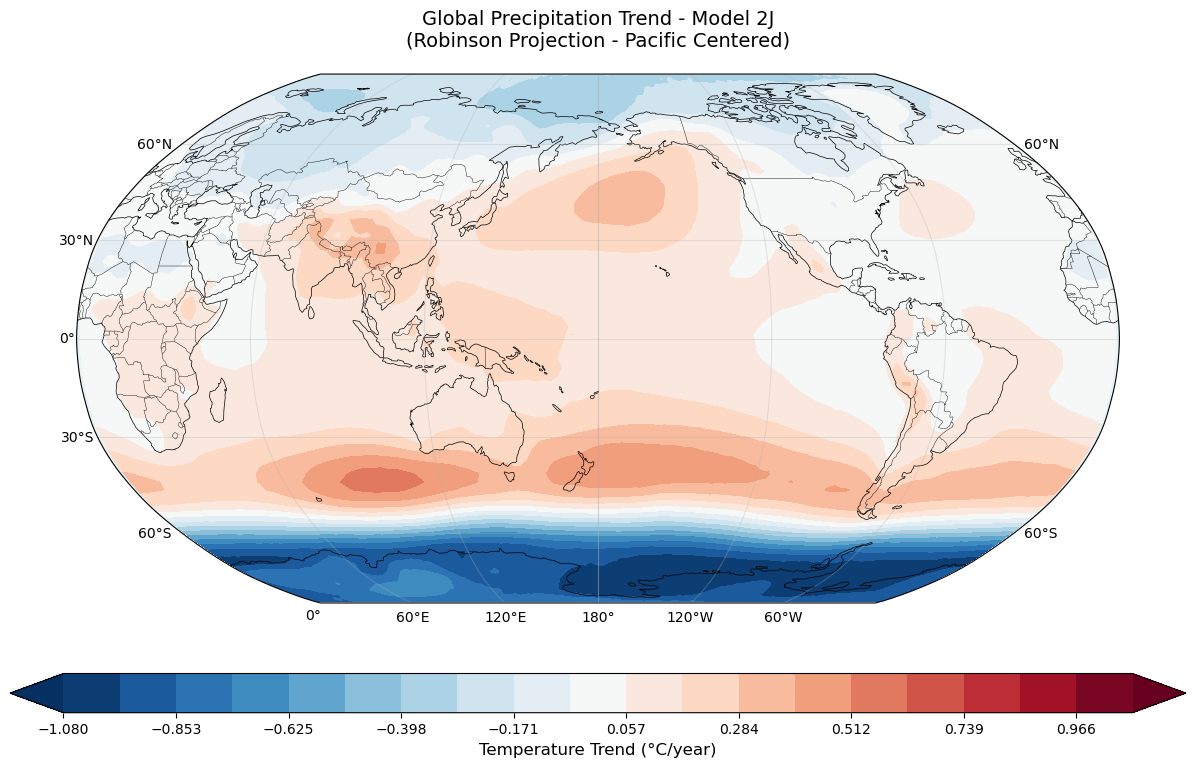

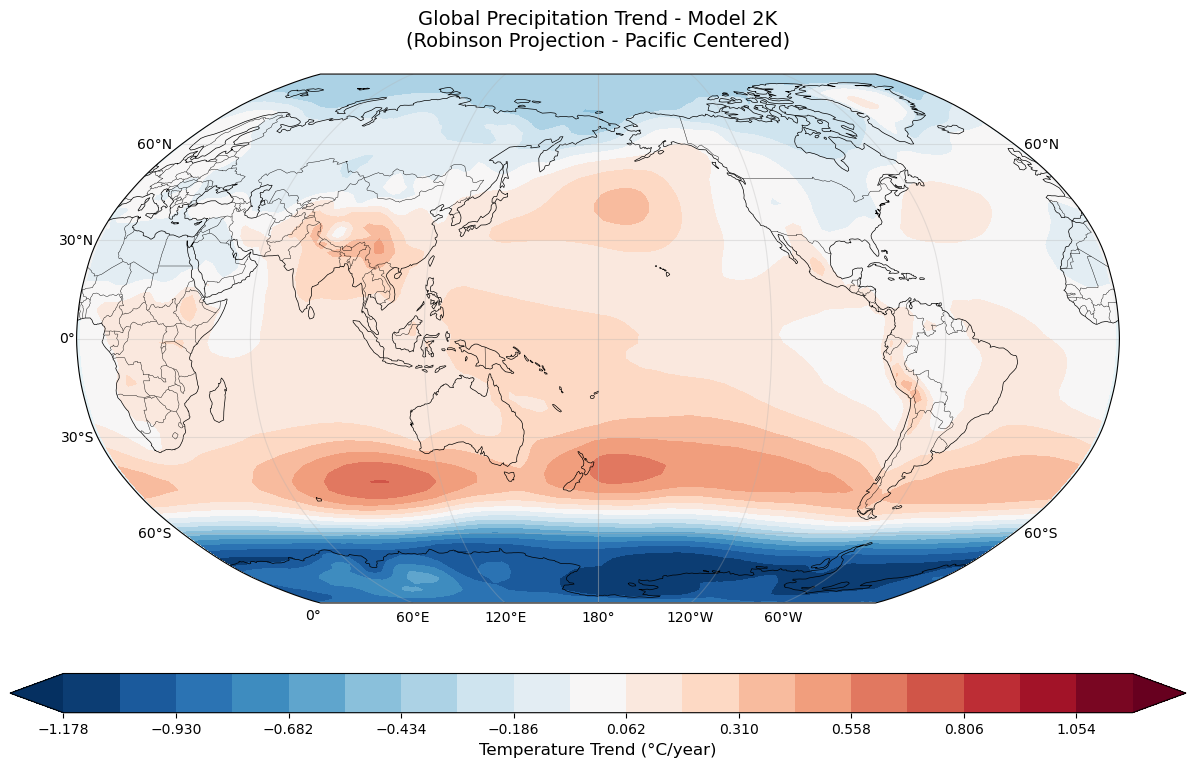

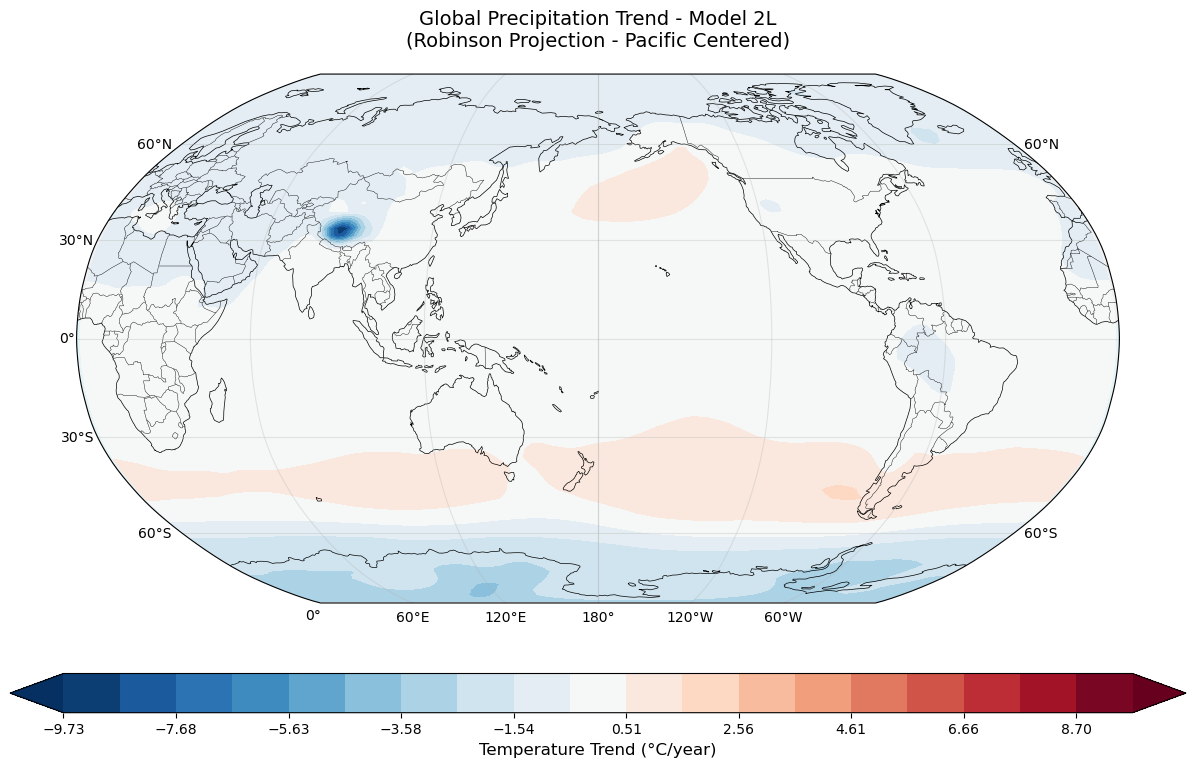

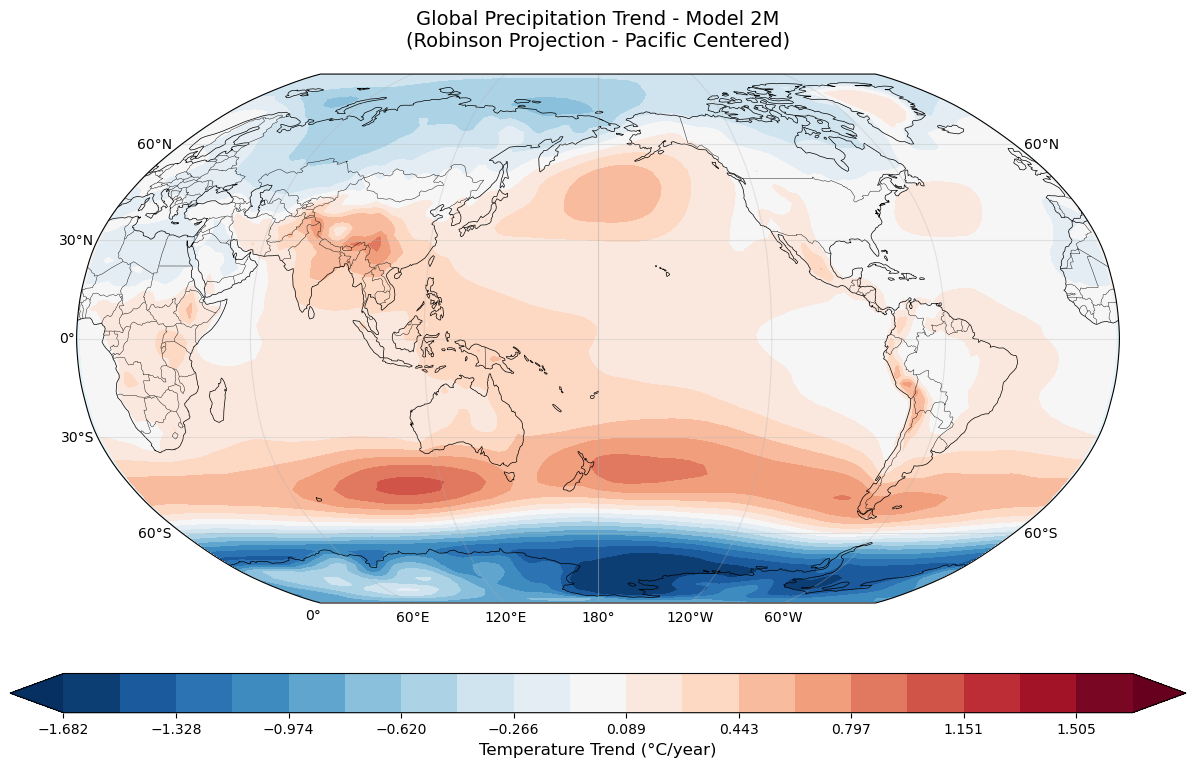

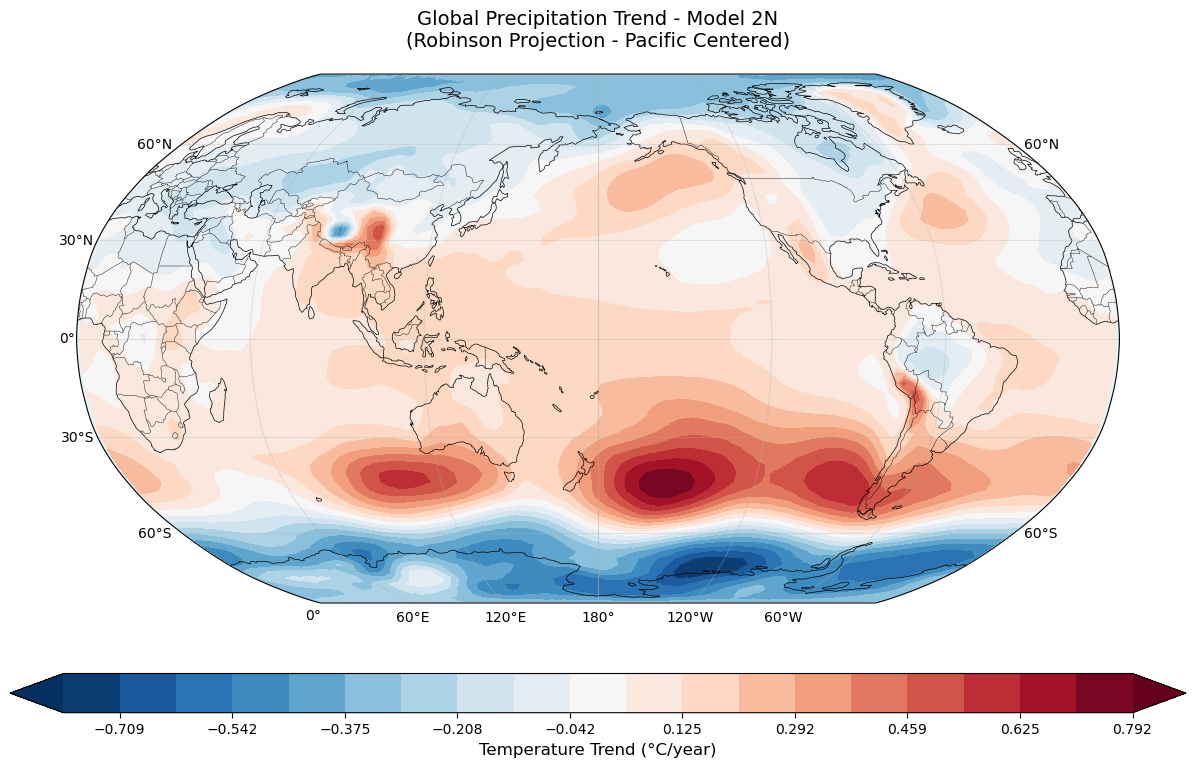

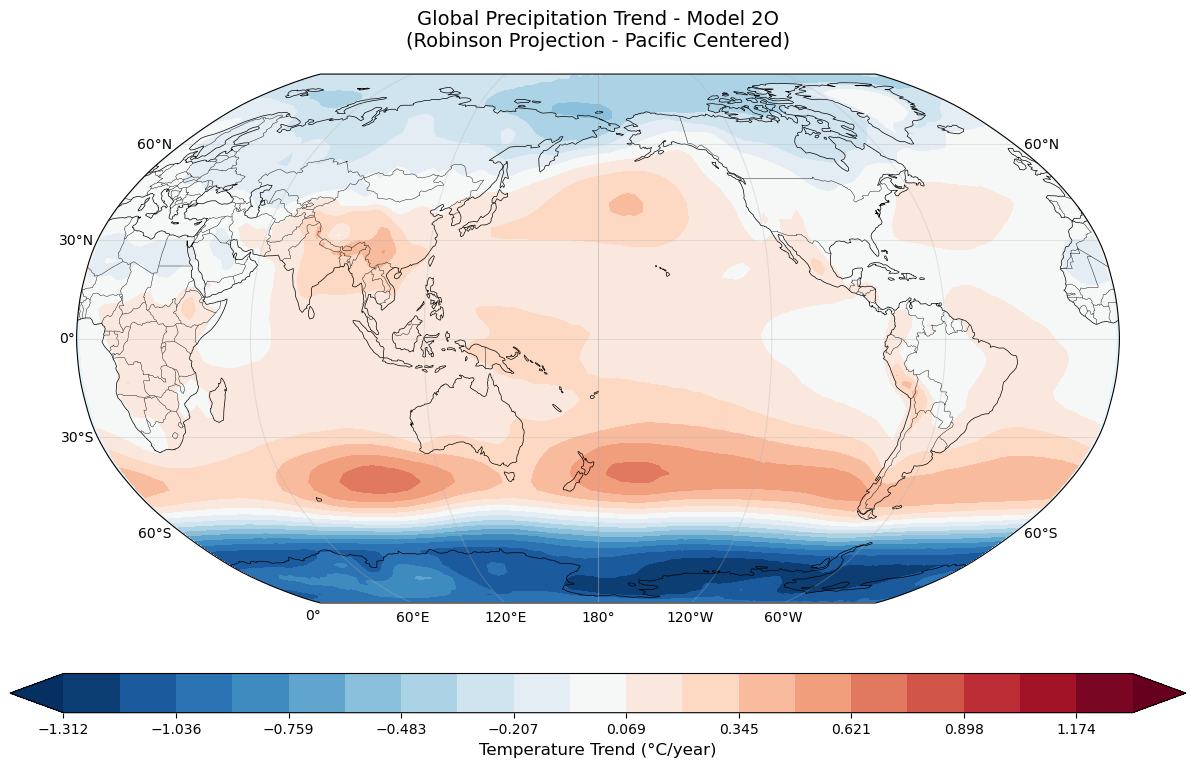

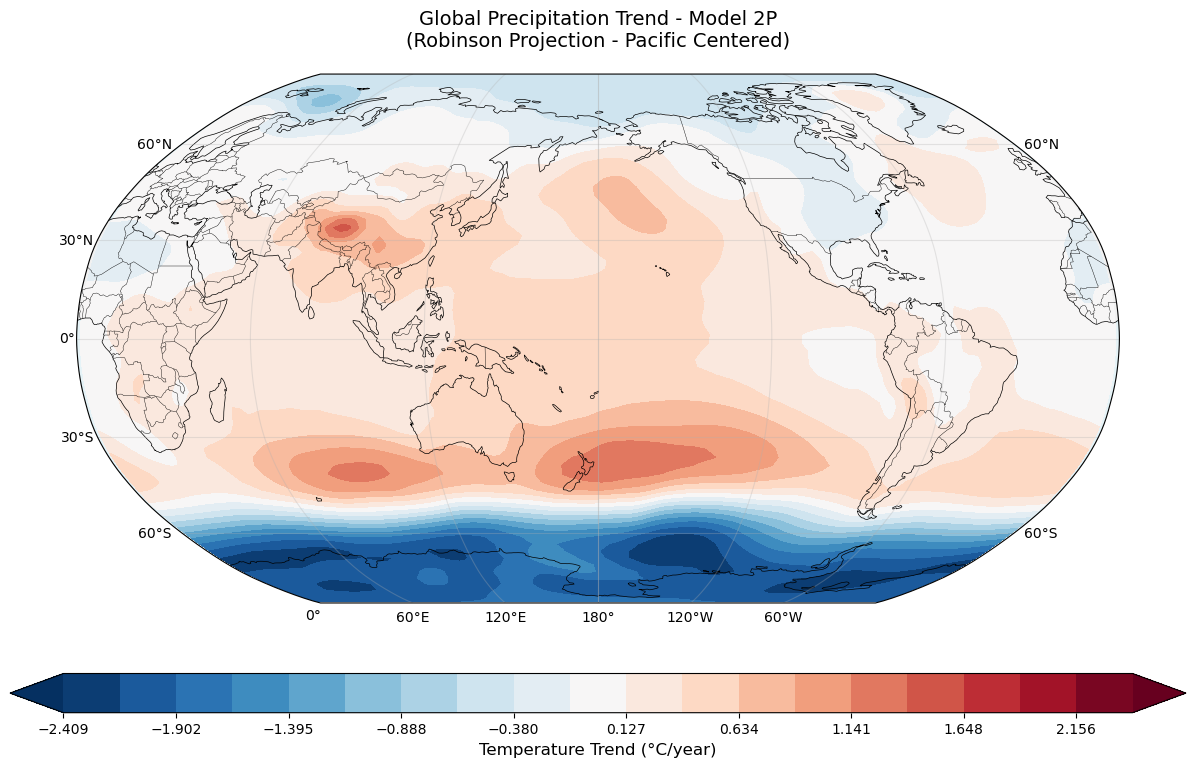

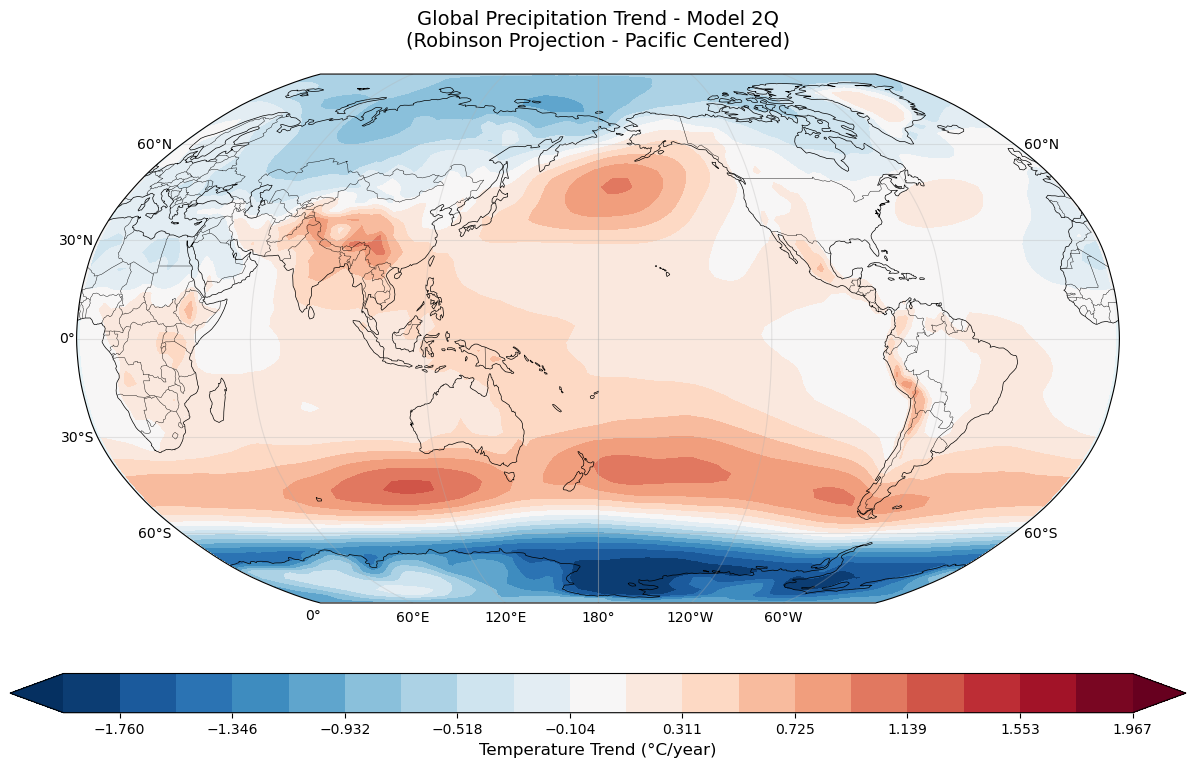

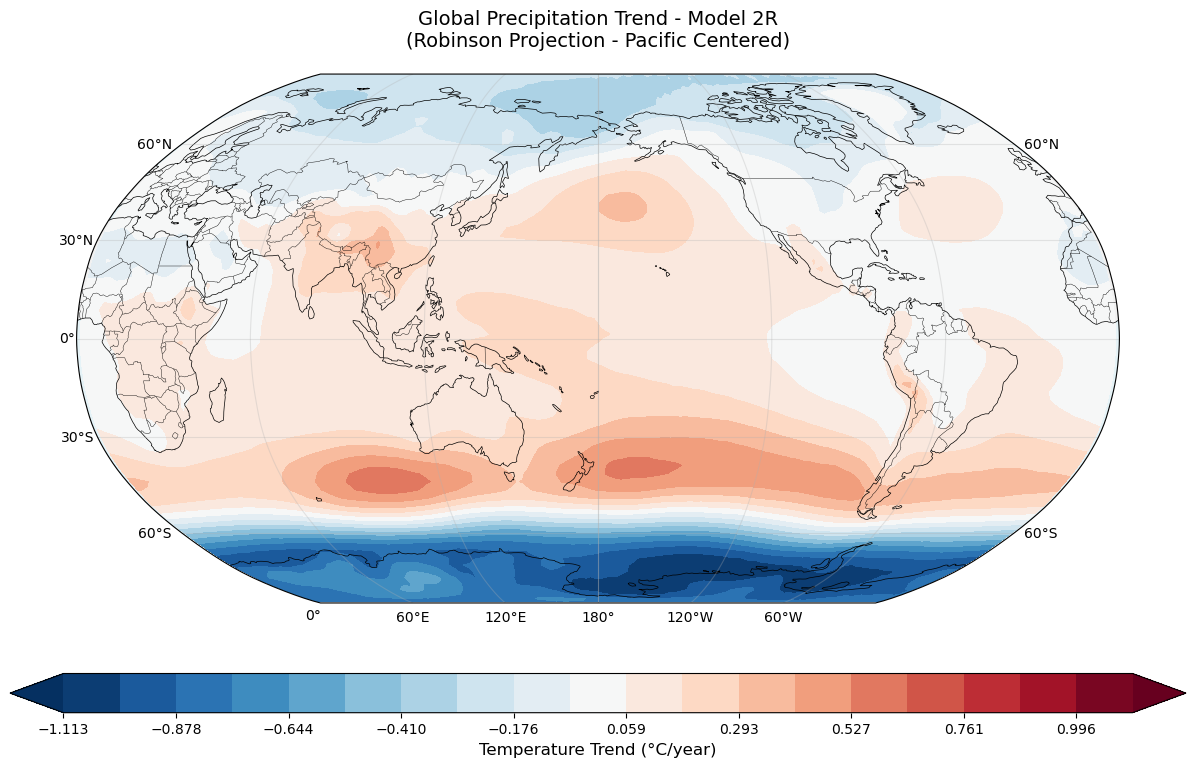

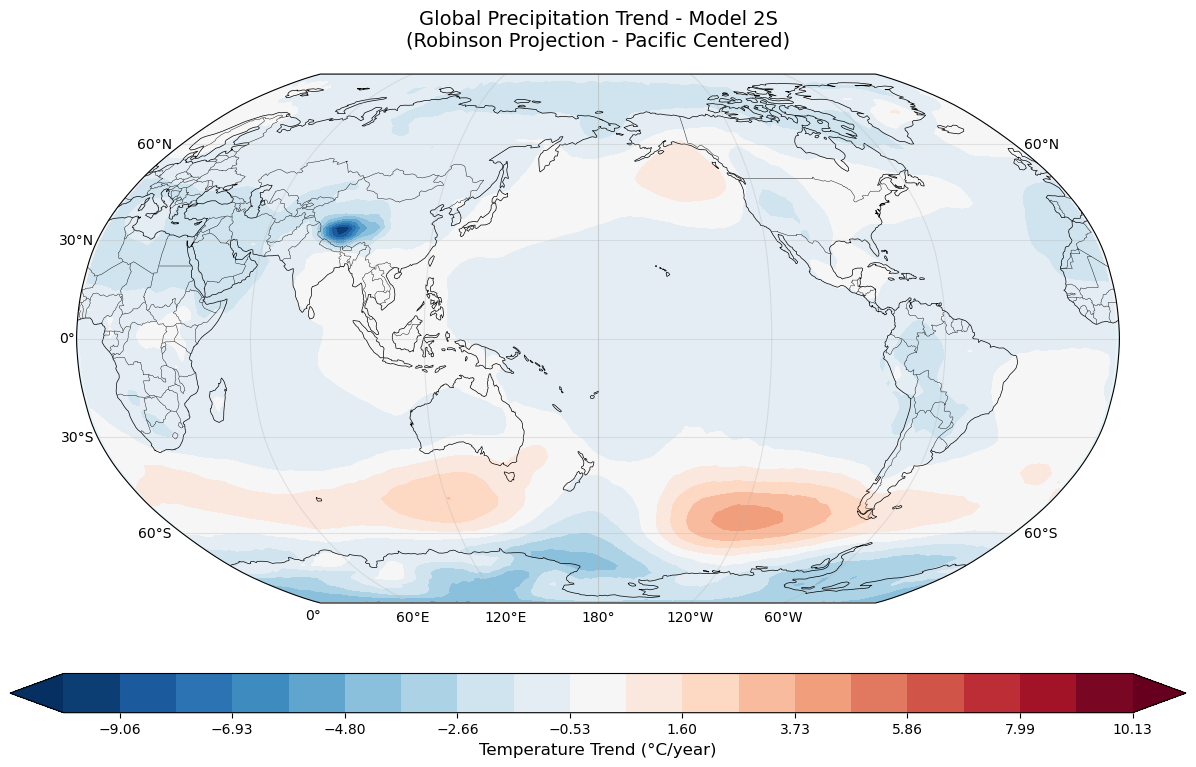

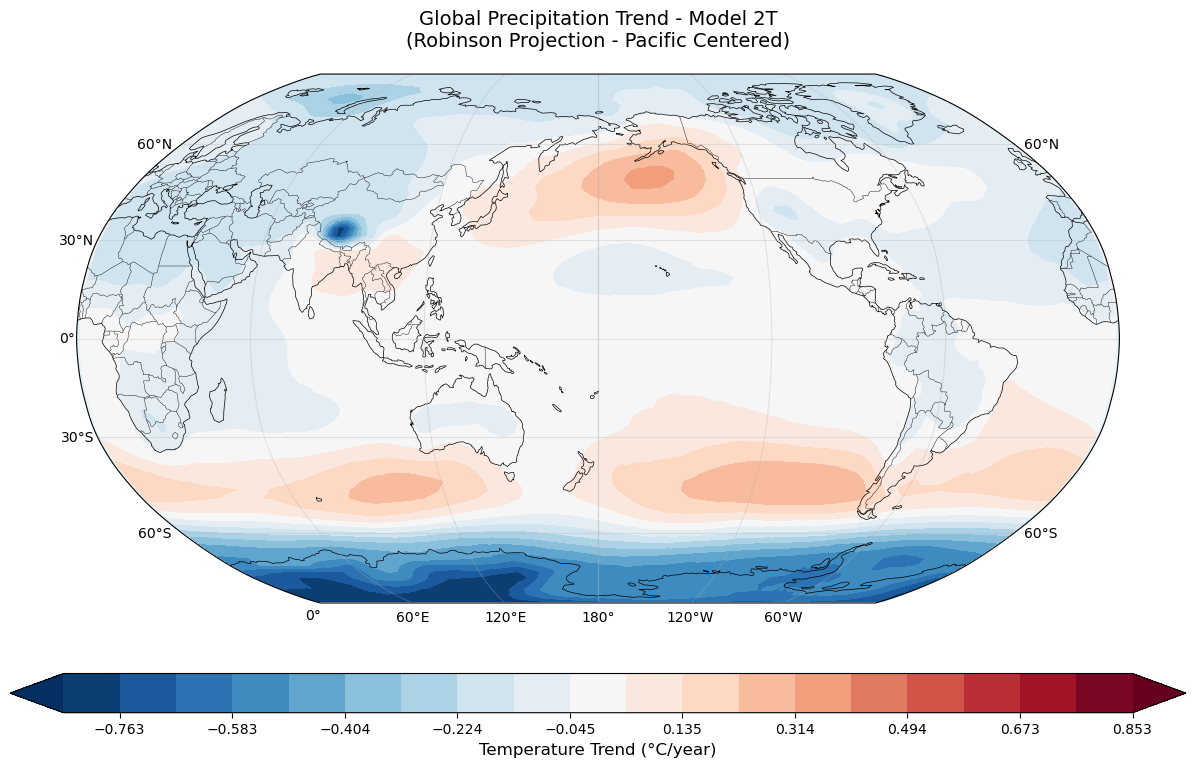

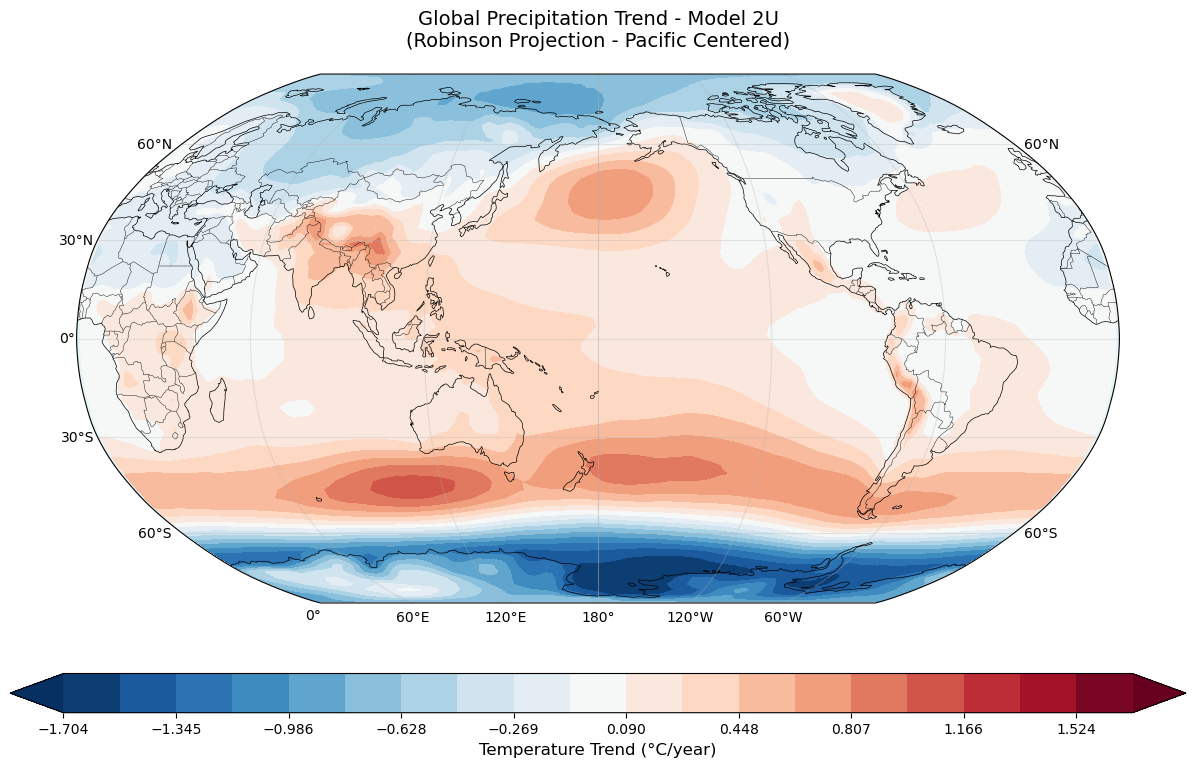

In [25]:
# display the trend map for the first test model
for idx_run in range(trends_ridge_smooth_fullmap.shape[0]):
    fig = visualizer.plot_robinson_projection(trends_ridge_fullmap, 
                                    title="Global Precipitation Trend",
                                    cmap='RdBu_r',
                                    run_idx=idx_run,
                                    central_longitude=180)

## Cross validation to select the best combination (ridge penalty param, rank)

         CROSS-VALIDATION LAMBDA OPTIMIZATION
Performing cross-validation to optimize lambda for worst-case performance...
Cross-validation with 5 folds for 3 lambda values...
Optimization objective: worst_case
  Testing λ = 10.0


    Mean NRMSE: 3.7716
   Q75 NRMSE: 2.0662
   Q90 NRMSE: 8.3539
   Q95 NRMSE: 10.4499
    Worst NRMSE: 12.5458
    NRMSE Variance: 19.4144
  Testing λ = 100.0
    Mean NRMSE: 5.0835
   Q75 NRMSE: 8.7315
   Q90 NRMSE: 10.8493
   Q95 NRMSE: 11.5552
    Worst NRMSE: 12.2611
    NRMSE Variance: 21.0869
  Testing λ = 500.0
    Mean NRMSE: 1.9437
   Q75 NRMSE: 2.0459
   Q90 NRMSE: 4.0111
   Q95 NRMSE: 4.6662
    Worst NRMSE: 5.3212
    NRMSE Variance: 3.1192

Optimization complete!
Best λ = 500.0 (optimizing worst_nrmse)
Best worst_nrmse: 5.3212


/home/vcohen/cope/ForceSMIP/algorithms.py:877: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/vcohen/.conda/envs/cope/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


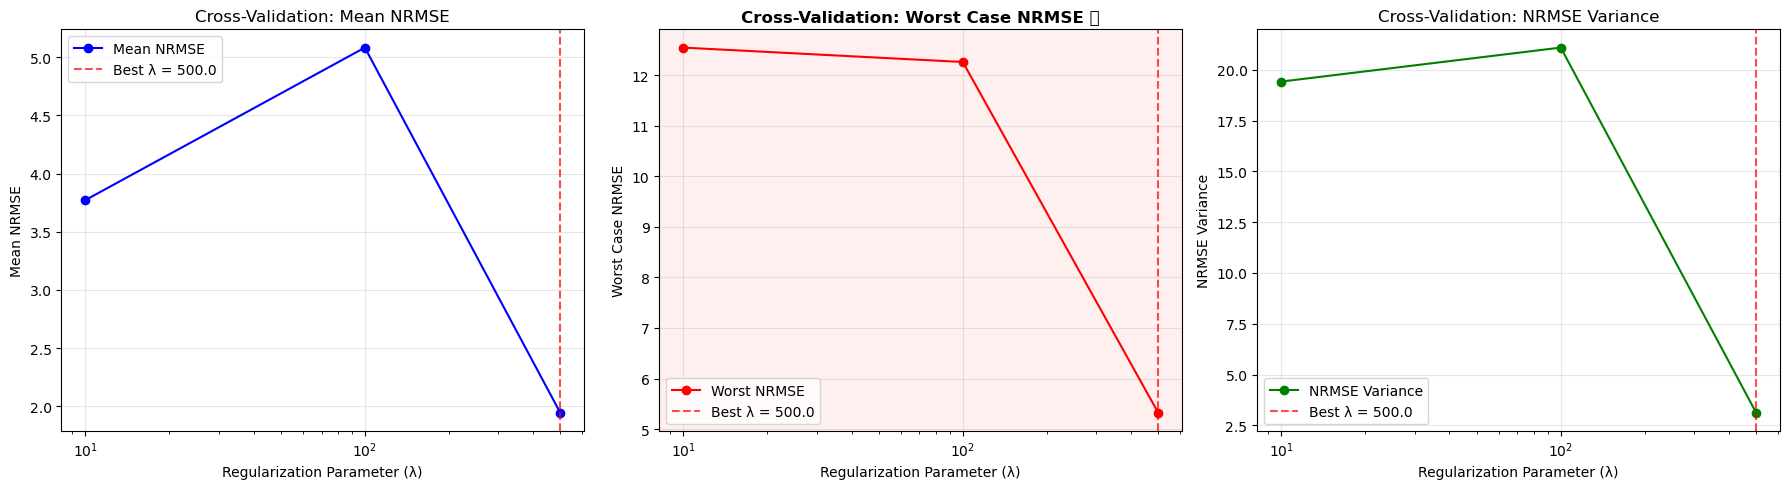


🎯 OPTIMAL LAMBDA (CV-optimized): 500.0
   Worst-case NRMSE: 5.3212
   Mean NRMSE: 1.9437


In [21]:
## 6.5 Cross-Validation to get the best Lambda Optimization

print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Import the cross-validation function
from algorithms import cross_validation_lambda_optimization, cross_validation_lambda_rank_optimization,\
                        plot_cv_lambda_results, plot_cv_lambda_rank_results

# Define lambda values to test (broader range for better optimization)
lambda_values_cv = [10.0, 100.0, 500.0]


print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective


cv_optimization = cross_validation_lambda_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)

# Plot cross-validation results
fig_cv = plot_cv_lambda_results(cv_optimization, figsize=(18, 5))
plt.show()


# Extract optimal lambda
optimal_lambda_cv = cv_optimization['best_lambda']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['mean_nrmse']:.4f}")

         CROSS-VALIDATION LAMBDA OPTIMIZATION
Performing cross-validation to optimize lambda and rank for worst-case performance...
Cross-validation with 5 folds for 3 lambda values...
Optimization objective: worst_case
  Testing λ = 10.0

Setting up low-rank solver...
Computing SVD for low-rank approximations...
Solving ridge regression with λ=10.0
Input shape: X=torch.Size([29835, 10368]), Y=torch.Size([29835, 10368])
Reshaped: X=torch.Size([29835, 10368]), Y=torch.Size([29835, 10368])
Ridge weights computed: torch.Size([10368, 10368])


SVD computed: U=torch.Size([40203, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.043699 to 572008.250000
Computed solutions for ranks: [5, 10]

Setting up low-rank solver...
Computing SVD for low-rank approximations...
Solving ridge regression with λ=10.0
Input shape: X=torch.Size([35360, 10368]), Y=torch.Size([35360, 10368])
Reshaped: X=torch.Size([35360, 10368]), Y=torch.Size([35360, 10368])
Ridge weights computed: torch.Size([10368, 10368])
SVD computed: U=torch.Size([45728, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.039588 to 547965.000000
Computed solutions for ranks: [5, 10]

Setting up low-rank solver...
Computing SVD for low-rank approximations...
Solving ridge regression with λ=10.0
Input shape: X=torch.Size([34255, 10368]), Y=torch.Size([34255, 10368])
Reshaped: X=torch.Size([34255, 10368]), Y=torch.Size([34255, 10368])
Ridge weights computed: torch.Size([10368, 10368])
SVD computed: U=torch.

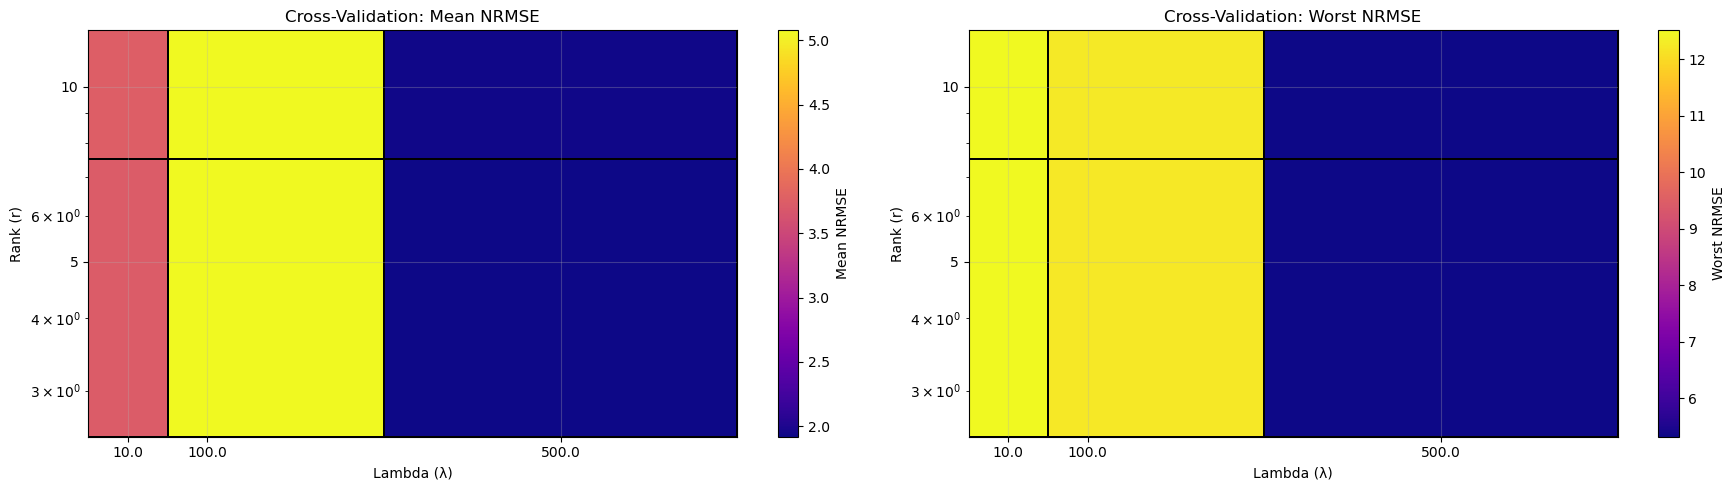


🎯 OPTIMAL LAMBDA (CV-optimized): 500.0
🎯 OPTIMAL RANK (CV-optimized): 10
   Worst-case NRMSE: 5.3210
   Mean NRMSE: 1.9415


In [22]:
## 6.5 Cross-Validation Lambda Optimization
print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Define lambda values to test (broader range for better optimization)
lambda_values_cv = [10.0, 100.0, 500.0]
rank_values_cv = [5, 10]




print("Performing cross-validation to optimize lambda and rank for worst-case performance...")

# Optimize lambda and rank using cross-validation with worst-case objective
cv_optimization_lr = cross_validation_lambda_rank_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    rank_values=rank_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)

# # Plot cross-validation results
fig_cv = plot_cv_lambda_rank_results(cv_optimization_lr, figsize=(18, 5))
plt.show()

# Extract optimal lambda
optimal_lambda_cv_lr = cv_optimization_lr['best_lambda']
optimal_rank_cv_lr = cv_optimization_lr['best_rank']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv_lr}")
print(f"🎯 OPTIMAL RANK (CV-optimized): {optimal_rank_cv_lr}")
print(f"   Worst-case NRMSE: {cv_optimization_lr['cv_results'][(optimal_lambda_cv_lr, optimal_rank_cv_lr)]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization_lr['cv_results'][(optimal_lambda_cv_lr, optimal_rank_cv_lr)]['mean_nrmse']:.4f}")

In [ ]:
# given the best lambda value, run the ridge regression again
w_ridge_cv = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, optimal_lambda_cv, verbose=True)


# given the best lambda and best rank, run the low-rank solver again
w_ridge_lr_cv =  ridge_regression(x_train_merged_filtered,y_train_merged_filtered, optimal_lambda_cv_lr, verbose=True)



lr_solver_cv = LowRankSolver()
lr_solver_cv.fit(x_train_merged_filtered, y_train_merged_filtered, w_ridge_lr_cv, verbose=True)
lr_solver_cv_solution = lr_solver_cv.get_multiple_ranks([optimal_rank_cv_lr], verbose=True)

Solving ridge regression with λ=500.0
Input shape: X=torch.Size([40885, 6837]), Y=torch.Size([40885, 6837])
Reshaped: X=torch.Size([40885, 6837]), Y=torch.Size([40885, 6837])
Ridge weights computed: torch.Size([6837, 6837])
Solving ridge regression with λ=500.0
Input shape: X=torch.Size([40885, 6837]), Y=torch.Size([40885, 6837])
Reshaped: X=torch.Size([40885, 6837]), Y=torch.Size([40885, 6837])
Ridge weights computed: torch.Size([6837, 6837])
Computing SVD for low-rank approximations...
Solving ridge regression with λ=tensor([[ 1.9459e-03,  1.6821e-03,  1.2152e-03,  ..., -8.1065e-06,
         -6.7487e-06, -6.3195e-06],
        [ 1.6341e-03,  1.6181e-03,  1.2771e-03,  ..., -2.4678e-04,
         -2.4874e-04, -2.4785e-04],
        [ 1.1160e-03,  1.2197e-03,  1.2045e-03,  ..., -1.4314e-04,
         -1.4764e-04, -1.4842e-04],
        ...,
        [ 4.0161e-05,  4.9904e-05,  6.0344e-05,  ...,  1.3344e-03,
          1.3261e-03,  1.3145e-03],
        [ 4.0526e-05,  4.9618e-05,  5.7462e-05,  .

/home/vcohen/cope/ForceSMIP/algorithms.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_augmented = torch.cat([x @ torch.sqrt(S_inv), torch.sqrt(torch.tensor(lambda_reg, dtype=x.dtype, device=x.device)) * I_p], dim=0)


_LinAlgError: linalg.svd: The algorithm failed to converge because the input matrix contained non-finite values.

In [ ]:
# Make predictions using different methods
print("Making predictions...")
# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

y_pred_ridge_smooth = x_test_smooth @ w_ridge
y_pred_ridge_lr_smooth = x_test_smooth @ w_ridge_lr

In [ ]:
# save the forced response predictions 